In [1]:
# NBVAL_SKIP
from jax import config
#config.update("jax_enable_x64", True)
config.update('jax_num_cpu_devices', 2)

In [2]:
#NBVAL_SKIP
import os

# Tell XLA to fake 2 host CPU devices
#os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=3'

# Only make GPU 0 and GPU 1 visible to JAX:
#os.environ['CUDA_VISIBLE_DEVICES'] = '1,2'

#os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]   = "false"

import jax

# Now JAX will list two CpuDevice entries
print(jax.devices())
# → [CpuDevice(id=0), CpuDevice(id=1)]

[CpuDevice(id=0), CpuDevice(id=1)]


In [3]:
# NBVAL_SKIP
import os
#os.environ['SPS_HOME'] = '/mnt/storage/annalena_data/sps_fsps'
#os.environ['SPS_HOME'] = '/home/annalena/sps_fsps'
os.environ['SPS_HOME'] = '/Users/annalena/Documents/GitHub/fsps'
#os.environ['SPS_HOME'] = '/export/home/aschaibl/fsps'

# Load ssp template from FSPS

In [4]:
# NBVAL_SKIP
from rubix.spectra.ssp.factory import get_ssp_template
ssp_fsps = get_ssp_template("FSPS")

2025-09-26 08:18:20,577 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|


2025-09-26 08:18:20,578 - rubix - INFO - Rubix version: 0.0.post474+ga7da79fea.d20250902
2025-09-26 08:18:20,578 - rubix - INFO - JAX version: 0.5.0
2025-09-26 08:18:20,578 - rubix - INFO - Running on [CpuDevice(id=0), CpuDevice(id=1)] devices


In [5]:
# NBVAL_SKIP
age_values = ssp_fsps.age
print(age_values.shape)

metallicity_values = ssp_fsps.metallicity
print(metallicity_values.shape)

(107,)
(12,)


In [6]:
# NBVAL_SKIP
index_age = 90
index_metallicity = 9

#initial_metallicity_index = 5
#initial_age_index = 70
initial_metallicity_index = 10
initial_age_index = 104

learning_all = 1e-2
tol = 1e-10

print(f"start age: {age_values[initial_age_index]}, start metallicity: {metallicity_values[initial_metallicity_index]}")
print(f"target age: {age_values[index_age]}, target metallicity: {metallicity_values[index_metallicity]}")

start age: 15.848933219909668, start metallicity: 0.025251565501093864
target age: 3.1622776985168457, target metallicity: 0.014199999161064625


# Configure pipeline

In [7]:
# NBVAL_SKIP
from rubix.core.pipeline import RubixPipeline
import os
config = {
    "pipeline":{"name": "calc_gradient",},
    
    "logger": {
        "log_level": "DEBUG",
        "log_file_path": None,
        "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    },
    "data": {
        "name": "IllustrisAPI",
        "args": {
            "api_key": os.environ.get("ILLUSTRIS_API_KEY"),
            "particle_type": ["stars"],
            "simulation": "TNG50-1",
            "snapshot": 99,
            "save_data_path": "data",
        },
        
        "load_galaxy_args": {
        "id": 14,
        "reuse": True,
        },
        
        "subset": {
            "use_subset": True,
            "subset_size": 2,
        },
    },
    "simulation": {
        "name": "IllustrisTNG",
        "args": {
            "path": "data/galaxy-id-14.hdf5",
        },
    
    },
    "output_path": "output",

    "telescope":
        {"name": "TESTGRADIENT",
         "psf": {"name": "gaussian", "size": 5, "sigma": 0.6},
         "lsf": {"sigma": 1.2},
         "noise": {"signal_to_noise": 100,"noise_distribution": "normal"},
         },
    "cosmology":
        {"name": "PLANCK15"},
        
    "galaxy":
        {"dist_z": 0.1,
         "rotation": {"type": "edge-on"},
        },
        
    "ssp": {
        "template": {
            "name": "FSPS"
        },
        "dust": {
                "extinction_model": "Cardelli89",
                "dust_to_gas_ratio": 0.01,
                "dust_to_metals_ratio": 0.4,
                "dust_grain_density": 3.5,
                "Rv": 3.1,
            },
    },        
}

In [8]:
# NBVAL_SKIP
pipe = RubixPipeline(config)
inputdata = pipe.prepare_data()
output = pipe.run_sharded(inputdata)

/Users/annalena/Documents/GitHub/rubix/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /Users/annalena/Documents/GitHub/rubix/rubix/telescope/telescopes.yaml
  warnings.warn(
2025-09-26 08:18:21,138 - rubix - INFO - Getting rubix data...
2025-09-26 08:18:21,138 - rubix - INFO - Rubix galaxy file already exists, skipping conversion
/Users/annalena/miniconda3/envs/rubix/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:188: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)
/Users/annalena/Documents/GitHub/rubix/rubix/core/data.py:537: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and wil

# Set target values

In [9]:
# NBVAL_SKIP
import jax.numpy as jnp

inputdata.stars.age = jnp.array([age_values[index_age], age_values[index_age]])
inputdata.stars.metallicity = jnp.array([metallicity_values[index_metallicity], metallicity_values[index_metallicity]])
inputdata.stars.mass = jnp.array([[1.0], [1.0]])
inputdata.stars.velocity = jnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
inputdata.stars.coords = jnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])

In [10]:
# NBVAL_SKIP
targetdata = pipe.run_sharded(inputdata)

2025-09-26 08:18:23,739 - rubix - INFO - Setting up the pipeline...
2025-09-26 08:18:23,740 - rubix - DEBUG - Pipeline Configuration: {'Transformers': {'rotate_galaxy': {'name': 'rotate_galaxy', 'depends_on': None, 'args': [], 'kwargs': {}}, 'spaxel_assignment': {'name': 'spaxel_assignment', 'depends_on': 'rotate_galaxy', 'args': [], 'kwargs': {}}, 'calculate_datacube_particlewise': {'name': 'calculate_datacube_particlewise', 'depends_on': 'spaxel_assignment', 'args': [], 'kwargs': {}}, 'convolve_psf': {'name': 'convolve_psf', 'depends_on': 'calculate_datacube_particlewise', 'args': [], 'kwargs': {}}, 'convolve_lsf': {'name': 'convolve_lsf', 'depends_on': 'convolve_psf', 'args': [], 'kwargs': {}}, 'apply_noise': {'name': 'apply_noise', 'depends_on': 'convolve_lsf', 'args': [], 'kwargs': {}}}}
2025-09-26 08:18:23,740 - rubix - DEBUG - Roataion Type found: edge-on
2025-09-26 08:18:23,742 - rubix - INFO - Calculating spatial bin edges...
/Users/annalena/Documents/GitHub/rubix/rubix/telesc

In [11]:
# NBVAL_SKIP
print(targetdata[0,0,:].shape)

(466,)


# Set initial datracube

In [12]:
# NBVAL_SKIP
inputdata.stars.age = jnp.array([age_values[initial_age_index], age_values[initial_age_index]])
inputdata.stars.metallicity = jnp.array([metallicity_values[initial_metallicity_index], metallicity_values[initial_metallicity_index]])
inputdata.stars.mass = jnp.array([[1.0], [1.0]])
inputdata.stars.velocity = jnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
inputdata.stars.coords = jnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])

In [13]:
# NBVAL_SKIP
initialdata = pipe.run_sharded(inputdata)

2025-09-26 08:18:25,336 - rubix - INFO - Setting up the pipeline...
2025-09-26 08:18:25,336 - rubix - DEBUG - Pipeline Configuration: {'Transformers': {'rotate_galaxy': {'name': 'rotate_galaxy', 'depends_on': None, 'args': [], 'kwargs': {}}, 'spaxel_assignment': {'name': 'spaxel_assignment', 'depends_on': 'rotate_galaxy', 'args': [], 'kwargs': {}}, 'calculate_datacube_particlewise': {'name': 'calculate_datacube_particlewise', 'depends_on': 'spaxel_assignment', 'args': [], 'kwargs': {}}, 'convolve_psf': {'name': 'convolve_psf', 'depends_on': 'calculate_datacube_particlewise', 'args': [], 'kwargs': {}}, 'convolve_lsf': {'name': 'convolve_lsf', 'depends_on': 'convolve_psf', 'args': [], 'kwargs': {}}, 'apply_noise': {'name': 'apply_noise', 'depends_on': 'convolve_lsf', 'args': [], 'kwargs': {}}}}
2025-09-26 08:18:25,337 - rubix - DEBUG - Roataion Type found: edge-on
2025-09-26 08:18:25,338 - rubix - INFO - Calculating spatial bin edges...
/Users/annalena/Documents/GitHub/rubix/rubix/telesc

# Adam optimizer

In [14]:
# NBVAL_SKIP
from rubix.pipeline import linear_pipeline as pipeline

pipeline_instance = RubixPipeline(config)

pipeline_instance._pipeline = pipeline.LinearTransformerPipeline(
    pipeline_instance.pipeline_config, 
    pipeline_instance._get_pipeline_functions()
)
pipeline_instance._pipeline.assemble()
pipeline_instance.func = pipeline_instance._pipeline.compile_expression()

/Users/annalena/Documents/GitHub/rubix/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /Users/annalena/Documents/GitHub/rubix/rubix/telescope/telescopes.yaml
  warnings.warn(
2025-09-26 08:18:26,807 - rubix - INFO - Setting up the pipeline...
2025-09-26 08:18:26,807 - rubix - DEBUG - Pipeline Configuration: {'Transformers': {'rotate_galaxy': {'name': 'rotate_galaxy', 'depends_on': None, 'args': [], 'kwargs': {}}, 'spaxel_assignment': {'name': 'spaxel_assignment', 'depends_on': 'rotate_galaxy', 'args': [], 'kwargs': {}}, 'calculate_datacube_particlewise': {'name': 'calculate_datacube_particlewise', 'depends_on': 'spaxel_assignment', 'args': [], 'kwargs': {}}, 'convolve_psf': {'name': 'convolve_psf', 'depends_on': 'calculate_datacube_particlewise', 'args': [], 'kwargs': {}}, 'convolve_lsf': {'name': 'convolve_lsf', 'depends_on': 'convolve_psf', 'args': [], 'kwargs': {}}, 'apply_noise': {'name': 'apply_noise', 'depends_on': 'convolve_lsf',

In [15]:
# NBVAL_SKIP
import optax

def loss_only_wrt_age_metallicity(age, metallicity, base_data, target):
        
        base_data.stars.age = age*20
        base_data.stars.metallicity = metallicity*0.05

        output = pipeline_instance.func(base_data)
        #loss = jnp.sum((output.stars.datacube - target) ** 2)
        #loss = jnp.sum(optax.l2_loss(output.stars.datacube, target.stars.datacube))
        #loss = jnp.sum(optax.huber_loss(output.stars.datacube, target.stars.datacube))
        loss = jnp.sum(optax.cosine_distance(output.stars.datacube, target))
        
        return jnp.log10(loss) #loss#/0.03 #jnp.log10(loss #/5e-5)



In [16]:
#NBVAL_SKIP
import jax

def compute_gradient(age, metallicity, base_data, target):
    loss, grad_fn = jax.value_and_grad(loss_only_wrt_age_metallicity, argnums=(0,1))
    grads = grad_fn(age, metallicity, base_data, target)
    return grads, loss

In [17]:
#NBVAL_SKIP
#calculate gradient with jax
age_init = jnp.array([age_values[initial_age_index]/20, age_values[initial_age_index]/20])
metallicity_init = jnp.array([metallicity_values[initial_metallicity_index]/0.05, metallicity_values[initial_metallicity_index]/0.05])


# Pack both initial parameters into a dictionary.
params_init = {'age': age_init, 'metallicity': metallicity_init}
print(f"Initial parameters: {params_init}")

data = inputdata
target_value = targetdata

loss, grads = jax.value_and_grad(lambda p: loss_only_wrt_age_metallicity(p['age'], p['metallicity'], data, target_value))(params_init)

print("grads:", grads)
print("loss:", loss)

2025-09-26 08:18:27,083 - rubix - INFO - Rotating galaxy with alpha=90.0, beta=0.0, gamma=0.0
2025-09-26 08:18:27,083 - rubix - INFO - Rotating galaxy for simulation: IllustrisTNG
2025-09-26 08:18:27,084 - rubix - WARNING - Gas not found in particle_type, only rotating stellar component.
2025-09-26 08:18:27,127 - rubix - INFO - Assigning particles to spaxels...
2025-09-26 08:18:27,135 - rubix - INFO - Calculating Data Cube (combined per‐particle)…


Initial parameters: {'age': Array([0.7924467, 0.7924467], dtype=float32), 'metallicity': Array([0.5050313, 0.5050313], dtype=float32)}


2025-09-26 08:18:27,253 - rubix - DEBUG - Datacube shape: (1, 1, 466)
2025-09-26 08:18:27,254 - rubix - INFO - Convolving with PSF...
2025-09-26 08:18:27,255 - rubix - INFO - Convolving with LSF...
2025-09-26 08:18:27,258 - rubix - INFO - Applying noise to datacube with signal to noise ratio: 100 and noise distribution: normal


grads: {'age': Array([0.35268828, 0.35268828], dtype=float32), 'metallicity': Array([0.27147752, 0.27147752], dtype=float32)}
loss: -2.0571928


In [18]:
#NBVAL_SKIP
#calculate finite differnce
import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree

# 1) Skalares Loss über das ganze Param-PyTree
f = lambda p: loss_only_wrt_age_metallicity(p['age'], p['metallicity'], data, target_value)

# 2) Finite-Difference-Gradient (zentral) für beliebiges PyTree
def finite_diff_grad(f, params, eps=1e-5):
    flat, unravel = ravel_pytree(params)
    def f_flat(x): return f(unravel(x))

    def fd_i(i):
        e_i = jnp.zeros_like(flat).at[i].set(1.0)
        return (f_flat(flat + eps*e_i) - f_flat(flat - eps*e_i)) / (2*eps)

    g_flat = jax.vmap(fd_i)(jnp.arange(flat.size))
    return unravel(g_flat)

# 3) Anwenden: JAX-Grad + FD-Grad berechnen und vergleichen
grads_fd = finite_diff_grad(f, params_init, eps=1e-2)
print("grads_fd:", grads_fd)

grads_fd: {'age': Array([0.3533721, 0.3533721], dtype=float32), 'metallicity': Array([0.25966167, 0.2595067 ], dtype=float32)}


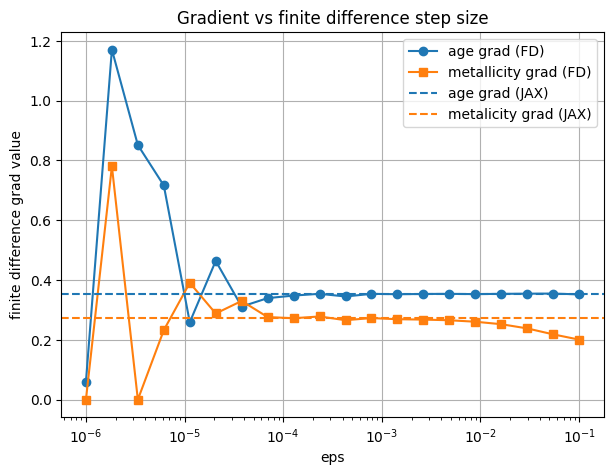

In [19]:
import matplotlib.pyplot as plt

# eps-Werte, über die wir scannen
eps_values = jnp.logspace(-6, -1, 20)  # von 1e-6 bis 1e-1

age_fd_values = []
metal_fd_values = []

for eps in eps_values:
    g_fd = finite_diff_grad(f, params_init, eps=float(eps))
    # g_fd hat die gleiche Struktur wie params_init:
    # {'age': array([..,..]), 'metallicity': array([..,..])}
    # Beispiel: nimm hier den Mittelwert pro Array
    age_fd_values.append(float(jnp.mean(g_fd['age'])))
    metal_fd_values.append(float(jnp.mean(g_fd['metallicity'])))

plt.figure(figsize=(7,5))
plt.semilogx(eps_values, age_fd_values, 'o-', label="age grad (FD)")
plt.semilogx(eps_values, metal_fd_values, 's-', label="metallicity grad (FD)")

# horizontale Linien = JAX-Gradient
plt.axhline(float(grads['age'][0]), color='C0', linestyle='--', label="age grad (JAX)")
plt.axhline(float(grads['metallicity'][0]), color='C1', linestyle='--', label="metalicity grad (JAX)")

plt.xlabel("eps")
plt.ylabel("finite difference grad value")
plt.title("Gradient vs finite difference step size")
plt.legend()
plt.grid(True)
plt.show()
